In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%pip install seaborn
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import plot_tree,DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
student_performance = fetch_ucirepo(id=320) 
  
# data (as pandas dataframes) 
X = student_performance.data.features 
y = student_performance.data.targets 
  
# metadata 
print(student_performance.metadata) 
  
# variable information 
print(student_performance.variables)

{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [58]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [59]:
y.head()

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [91]:
y

0      11
1      11
2      12
3      14
4      13
       ..
644    10
645    16
646     9
647    10
648    11
Name: G3, Length: 649, dtype: int64

In [60]:
X.shape


(649, 30)

In [61]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [62]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


In [63]:
X.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
dtype: int64

In [64]:
X.duplicated().sum()

np.int64(0)

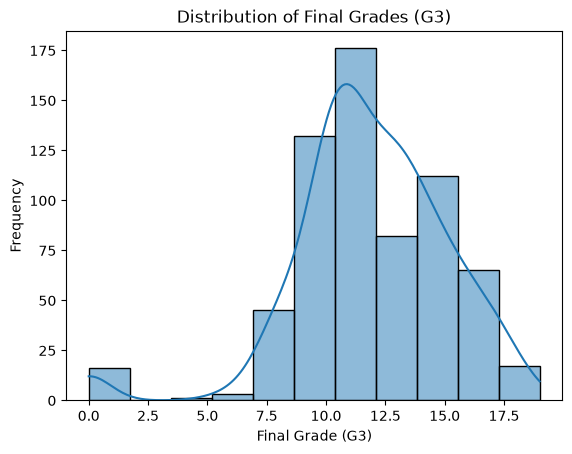

In [65]:
sns.histplot(y['G3'],bins=11, kde=True)

plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.show()

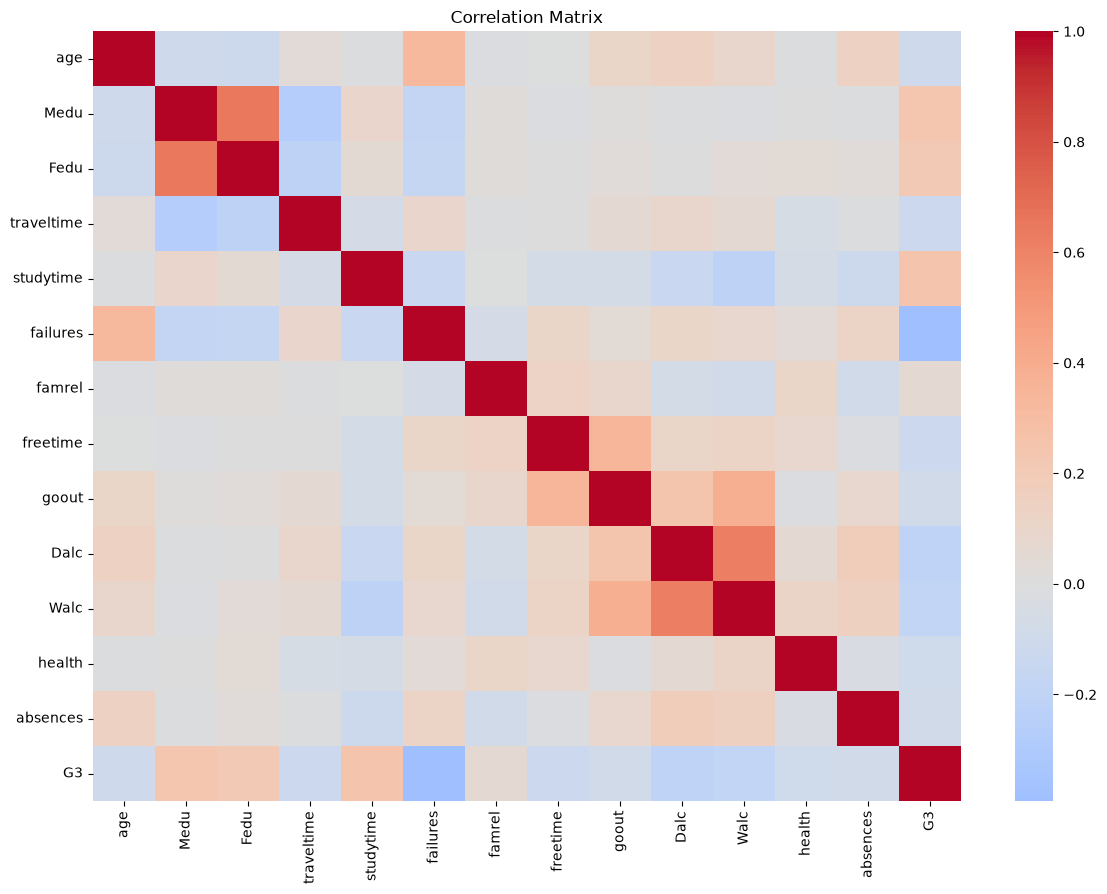

In [66]:
data = X.copy()
data['G3'] = y['G3']

correlation = data.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, cmap='coolwarm', center=0)

plt.title('Correlation Matrix')
plt.show()

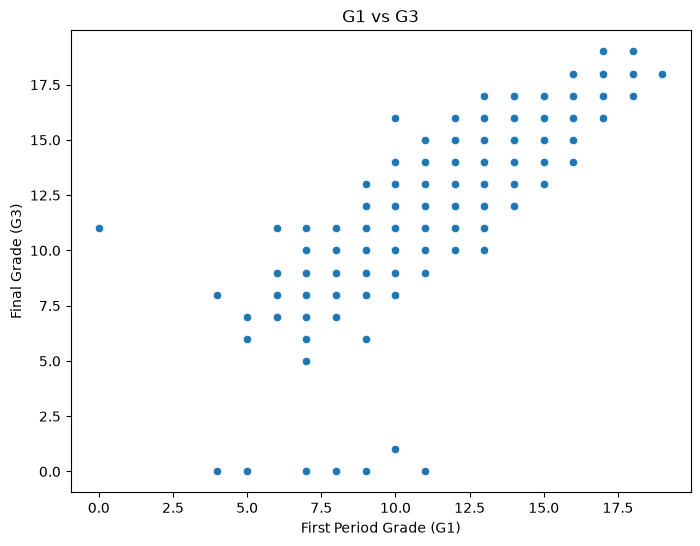

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y['G1'],
    y=y['G3']
)

plt.title('G1 vs G3')
plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.show()

Handle missing values

In [68]:

for column in data.columns:
    if data[column].dtype == 'object' or data[column].dtype == 'string':
        data[column] = data[column].fillna(data[column].mode()[0])
    else:
        data[column] = data[column].fillna(data[column].median())

print("\nMissing values after handling:")
print(data.isnull().sum())


Missing values after handling:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G3            0
dtype: int64


In [69]:
X = data.drop('G3', axis=1)
y = data['G3']

X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:")
print(X_encoded.shape)

print("\nEncoded data:")
print(X_encoded.head())

Shape after encoding:
(649, 39)

Encoded data:
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         0       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  ac

In [70]:
X_encoded.shape

(649, 39)

In [71]:
X_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


Normalize numirical features

In [72]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_encoded.columns
)

print(X_scaled.head())

        age      Medu      Fedu  traveltime  studytime  failures    famrel  \
0  1.031695  1.310216  1.540715    0.576718   0.083653 -0.374305  0.072606   
1  0.210137 -1.336039 -1.188832   -0.760032   0.083653 -0.374305  1.119748   
2 -1.432980 -1.336039 -1.188832   -0.760032   0.083653 -0.374305  0.072606   
3 -1.432980  1.310216 -0.278983   -0.760032   1.290114 -0.374305 -0.974536   
4 -0.611422  0.428131  0.630866   -0.760032   0.083653 -0.374305  0.072606   

   freetime     goout      Dalc  ...  guardian_mother  guardian_other  \
0 -0.171647  0.693785 -0.543555  ...         0.652973       -0.259681   
1 -0.171647 -0.157380 -0.543555  ...        -1.531457       -0.259681   
2 -0.171647 -1.008546  0.538553  ...         0.652973       -0.259681   
3 -1.123771 -1.008546 -0.543555  ...         0.652973       -0.259681   
4 -0.171647 -1.008546 -0.543555  ...        -1.531457       -0.259681   

   schoolsup_yes  famsup_yes  paid_yes  activities_yes  nursery_yes  \
0       2.923032   -1

Create averrage previous grades

In [73]:
original_targets = student_performance.data.targets
data['G1'] = original_targets['G1']
data['G2'] = original_targets['G2']
data['Average_Previous_Grades'] = data[['G1', 'G2']].mean(axis=1)

print(data[['G1', 'G2', 'Average_Previous_Grades']].head())

   G1  G2  Average_Previous_Grades
0   0  11                      5.5
1   9  11                     10.0
2  12  13                     12.5
3  14  14                     14.0
4  11  13                     12.0


Feature selection

In [74]:
y_class = (data['G3'] >= 10).astype(int)

X = data.drop('G3', axis=1)

X_encoded = pd.get_dummies(X, drop_first=True)

In [75]:
selector = SelectKBest(score_func=f_classif, k=10)

X_selected = selector.fit_transform(X_encoded, y_class)

selected_features = X_encoded.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Medu', 'Fedu', 'studytime', 'failures', 'G1', 'G2',
       'Average_Previous_Grades', 'school_MS', 'address_U', 'higher_yes'],
      dtype='str')


## **Logistic_Regression**

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (519, 10)
Testing shape: (130, 10)


In [77]:
model = LogisticRegression(random_state=42)

In [78]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In [79]:
y_pred_1 = logistic_model.predict(X_test)

NameError: name 'logistic_model' is not defined

In [ ]:
acc=accuracy_score(y_test,y_pred_1)
print(f"Accuracy with Logistic Regression: {acc*100:.2f}%")

Accuracy with Logistic Regression: 90.00%


In [ ]:
accuracy = accuracy_score(y_test, y_pred_1)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_1))

Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.70      0.68        20
           1       0.94      0.94      0.94       110

    accuracy                           0.90       130
   macro avg       0.81      0.82      0.81       130
weighted avg       0.90      0.90      0.90       130



## **Decision_Tree**

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [ ]:
y_pred_2 = decision_tree.predict(X_test)

In [ ]:
acc=accuracy_score(y_test,y_pred_2)
print(f'Accuracy with decision tree: {acc*100:.2f}%')

Accuracy with decision tree: 87.69%


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_2))


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        20
           1       0.93      0.93      0.93       110

    accuracy                           0.88       130
   macro avg       0.76      0.76      0.76       130
weighted avg       0.88      0.88      0.88       130



In [ ]:
print(f"Tree Depth: {tree.get_depth()}")
print(f"Leaves: {tree.get_n_leaves()}")

Tree Depth: 14
Leaves: 94


importance feature 

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature  Importance
6  Average_Previous_Grades    0.686465
2                studytime    0.075150
1                     Fedu    0.063117
0                     Medu    0.042346
7                school_MS    0.041132
5                       G2    0.027699
8                address_U    0.023018
3                 failures    0.022768
4                       G1    0.011315
9               higher_yes    0.006990


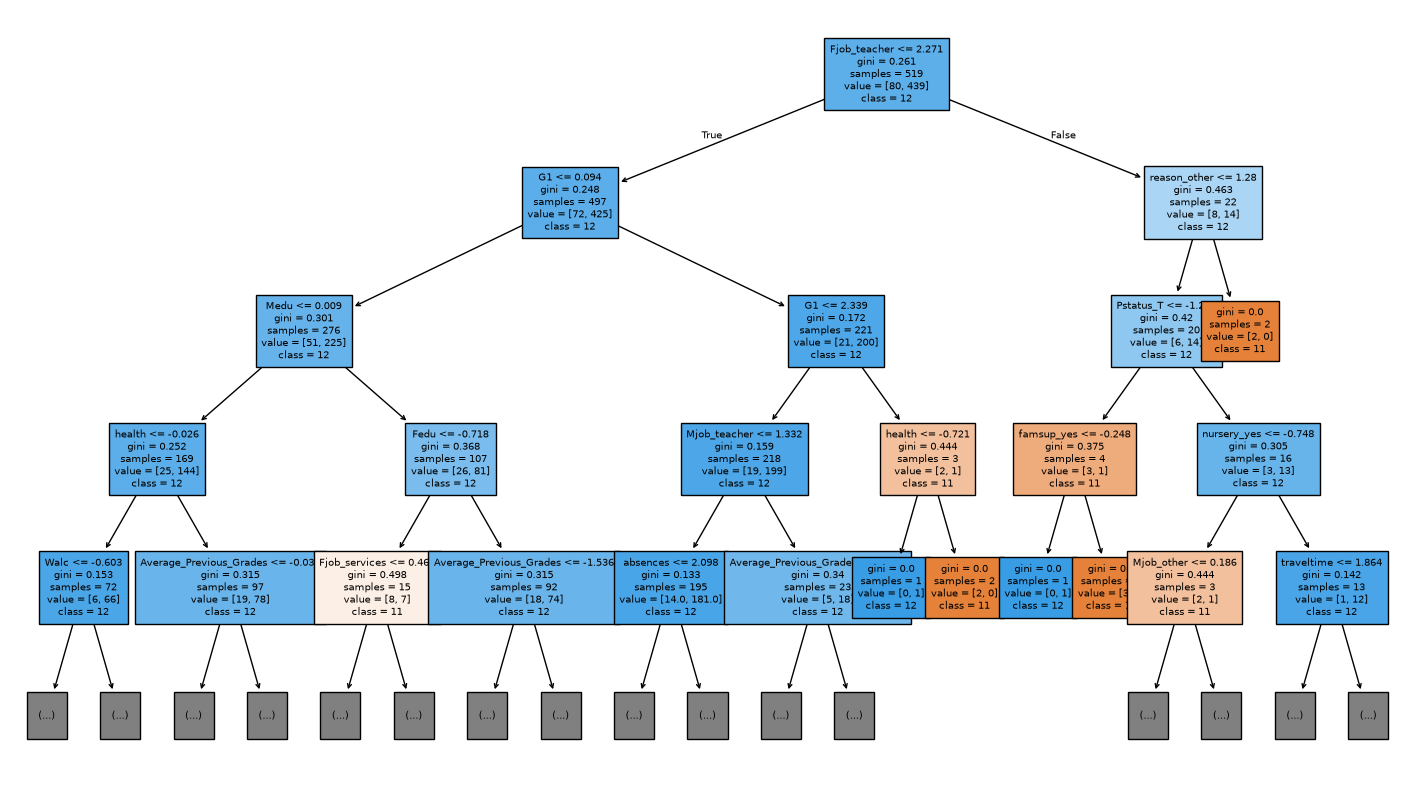

In [ ]:
plt.figure(figsize=(18,10))
plot_tree(
    tree,
    feature_names=X_encoded.columns.tolist(),
    class_names=y.unique().astype(str).tolist(),
    filled=True,
    fontsize=7,
    max_depth=4
)
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred_2)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_2))

Accuracy: 0.8769

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        20
           1       0.93      0.93      0.93       110

    accuracy                           0.88       130
   macro avg       0.76      0.76      0.76       130
weighted avg       0.88      0.88      0.88       130



## **SHAP, optional**

In [ ]:
native_importance = pd.DataFrame({
    'Features': selected_features,
    'Importance': decision_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

native_importance.head(10)

,Features,Importance
6,Average_Previous_Grades,0.686465
2,studytime,0.075150
1,Fedu,0.063117
0,Medu,0.042346
7,school_MS,0.041132
5,G2,0.027699
8,address_U,0.023018
3,failures,0.022768
4,G1,0.011315
9,higher_yes,0.006990


In [ ]:
native_importance.head(10)
#دي كدا global

,Features,Importance
6,Average_Previous_Grades,0.686465
2,studytime,0.075150
1,Fedu,0.063117
0,Medu,0.042346
7,school_MS,0.041132
5,G2,0.027699
8,address_U,0.023018
3,failures,0.022768
4,G1,0.011315
9,higher_yes,0.006990


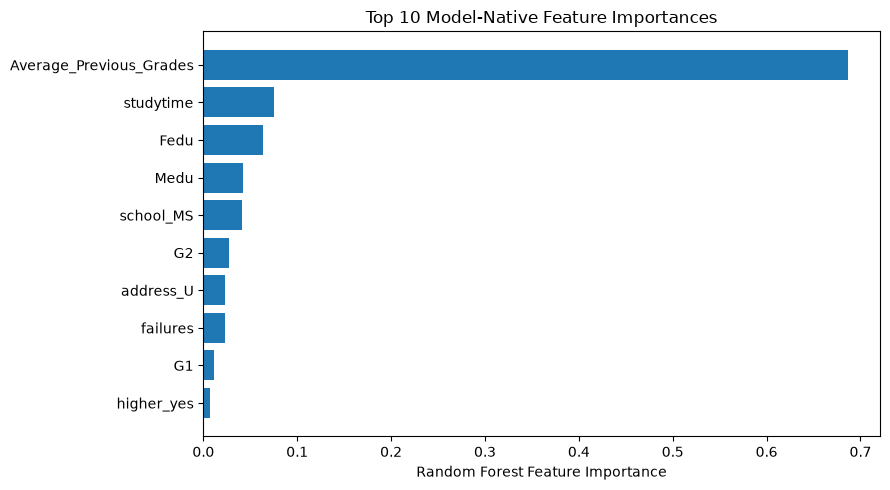

In [ ]:
plt.figure(figsize=(9, 5))

plt.barh(
    native_importance['Features'].head(10)[::-1],
    native_importance['Importance'].head(10)[::-1]
    )

plt.xlabel("Random Forest Feature Importance")

plt.title("Top 10 Model-Native Feature Importances")

plt.tight_layout()

plt.show()

In [ ]:
perm_result = permutation_importance(decision_tree,
                                     X_test,
                                     y_test,
                                     n_repeats=20,
                                     random_state=42,
                                     n_jobs=1)

perm_df = pd.DataFrame({
    'Features': selected_features,
    'Importance_mean': perm_result.importances_mean,
    'Importance_std': perm_result.importances_std
}).sort_values(by='Importance_mean', ascending=False)

In [ ]:
perm_df.head()

,Features,Importance_mean,Importance_std
14,G2,0.268846,0.026700
13,G1,0.065385,0.024627
23,Mjob_teacher,0.023077,0.008771
36,activities_yes,0.017308,0.013947
0,age,0.015385,0.013974


In [ ]:

x_train_numeric = x_train.astype(float)
x_test_numeric = x_test.astype(float)

%pip install shap
import shap

explainer = shap.Explainer(
    decision_tree,
    x_train_numeric,
    feature_names=selected_features
)

shap_values = explainer(
    x_test_numeric,
    check_additivity=False
)

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.68.0-cp314-cp314-win_amd64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.50.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
Using cached llvmlite-0.50.0-cp314-cp314-win_amd64.whl (43.0 MB)
Using cached numba-0.68.0-cp314-cp314-win_amd64.whl (2.8 MB)

   ---------------------------------------- 0/5 [tqdm]
   ---------------- ----------------------- 2/5 [llvmlite]
   ---------------- ----------------------- 2/5 [llvmlite]
   ---------------- ----------------------- 2/5 [llvmlite]
   ---------------- ----------------------- 2/5 [llvmlite]
   ---------------- ----------------------- 2/5 [llvmlite]
   ---------------- ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Engineer Omar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 519 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=519 when initializing the masker.


In [ ]:
shap_values.shape

(130, 42, 2)

In [ ]:
if len(
    shap_values.shape
) ==3:
    shap_class1 = shap_values[:,:,1]
else:
    shap_class1 = shap_values

In [ ]:
print("SHAP values shape:", shap_class1.values.shape)
print("Feature names:", len(shap_class1.feature_names))
print("Feature names:", shap_class1.feature_names)


SHAP values shape: (130, 42)
Feature names: 10
Feature names: ['Medu', 'Fedu', 'studytime', 'failures', 'G1', 'G2', 'Average_Previous_Grades', 'school_MS', 'address_U', 'higher_yes']


In [ ]:
sample_index = 0

sample = x_test[sample_index:sample_index + 1]

actual_label = y_test.iloc[sample_index]

sample = X_test[sample_index:sample_index + 1]  # shape (1, 10), matches decision_tree
predicted_label = decision_tree.predict(sample)[0]

predicted_probability = decision_tree.predict_proba(sample)[0]

print(f"Sample Index: {sample_index}")
print(f"Actual Label: {actual_label}")
print(f"Predicted Label: {predicted_label}")
print(f"Predicted Probability: {predicted_probability}\n")

Sample Index: 0
Actual Label: 1
Predicted Label: 1
Predicted Probability: [0. 1.]



In [87]:

# التنبؤ باستخدام النموذجين
predictions = {
    name: estimator.predict(X_test)
    for name, estimator in models.items()
}

comparison = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, pred) * 100,
        "Precision": precision_score(y_test, pred, zero_division=0) * 100,
        "Recall": recall_score(y_test, pred, zero_division=0) * 100,
        "F1-score": f1_score(y_test, pred, zero_division=0) * 100
    }
    for name, pred in predictions.items()
}).T

# عرض النتائج بالنسبة المئوية
display(comparison.round(2).style.format("{:.2f}%"))

,Accuracy,Precision,Recall,F1-score
Logistic Regression,90.00%,94.50%,93.64%,94.06%
Random Forest,88.46%,93.58%,92.73%,93.15%


In [88]:
print(X.columns.tolist())
print(student_performance.data.targets.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Average_Previous_Grades']
['G1', 'G2', 'G3']
